In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from collections import Counter 
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn 
import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


In [2]:
train_data=pd.read_csv(r"E:\Datasets\AG news\train.csv")
test_data=pd.read_csv(r"E:\Datasets\AG news\test.csv")

In [3]:
train_data.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB
None


In [5]:
train_data['text']=train_data["Title"]+" "+train_data["Description"]
test_data['text']=test_data["Title"]+" "+test_data["Description"]
train_data["Description"].head()

0    Reuters - Short-sellers, Wall Street's dwindli...
1    Reuters - Private investment firm Carlyle Grou...
2    Reuters - Soaring crude prices plus worries\ab...
3    Reuters - Authorities have halted oil export\f...
4    AFP - Tearaway world oil prices, toppling reco...
Name: Description, dtype: object

In [6]:
train_data['Class Index'].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [7]:
train_data["word_count"]=train_data["text"].apply(
    lambda x:len(str(x).split())
)
train_data['word_count'].describe()

count    120000.000000
mean         37.844617
std          10.088702
min           4.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64

In [8]:
train_data.isnull().sum()

Class Index    0
Title          0
Description    0
text           0
word_count     0
dtype: int64

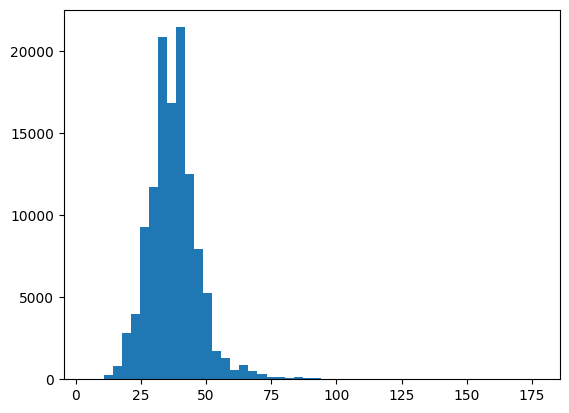

In [9]:
plt.hist(train_data["word_count"],bins=50)
plt.show()

In [10]:
train_data["word_count"].quantile([0.5,0.7,0.8,0.95,0.99])

0.50    37.0
0.70    42.0
0.80    44.0
0.95    53.0
0.99    70.0
Name: word_count, dtype: float64

In [11]:
for i in range(20):
    print(train_data["text"].iloc[i])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.
Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil

In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = text.replace("\\", " ")
    text = re.sub(r"#\d+;", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    # keep letters/numbers/basic punctuation
    text = re.sub(r"[^a-z0-9.,!?'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [13]:
train_data['text']=train_data['text'].apply(clean_text)
test_data['text']=test_data['text'].apply(clean_text)

In [14]:
train_data,val_data=train_test_split(
    train_data,
    test_size=0.1,
    random_state=42,
    stratify=train_data["Class Index"]
)

In [15]:
def tokenize(text):
    return text.split()
train_tk=train_data['text'].apply(tokenize)
test_tk=test_data['text'].apply(tokenize)
val_tk=val_data['text'].apply(tokenize)

In [16]:
counter=Counter()
for tokens in train_tk:
    counter.update(tokens)
print('number of unique words :',len(counter))
print(counter.most_common(10))

number of unique words : 103682
[('the', 184934), ('to', 108283), ('a', 101722), ('of', 88922), ('in', 86669), ('and', 62728), ('on', 51716), ('for', 45616), ('s', 28452), ('that', 24971)]


In [17]:
min_freq=2
vocab={
    "<PAD>":0,
    "<UNK>":1
}

for word,freq in counter.items():
    
    if freq>=min_freq:
        vocab[word]=len(vocab)
print("vocab_size",len(vocab))

vocab_size 61702


In [18]:
def numericallize(tokens,vocab):
    ids=[]
    for token in tokens:
        if token in vocab:
            ids.append(vocab[token])
        else:
            ids.append(vocab["<UNK>"])
    return ids 

In [19]:
x_train_ids=[
    numericallize(tokens,vocab)
    for tokens in train_tk
]
x_test_ids=[
    numericallize(tokens,vocab)
    for tokens in test_tk
]
x_val_ids=[
    numericallize(tokens,vocab)
    for tokens in val_tk
]


In [20]:
class AGNewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences=sequences
        self.labels=labels
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx],dtype=torch.long),
            torch.tensor(self.labels[idx],dtype=torch.long)
        )

def collate_fn(batch):
    sequences,labels=zip(*batch)
        
    sequences=pad_sequence(
    sequences,
    batch_first=True,
    padding_value=vocab["<PAD>"]
        )
        
    attention_mask=sequences!=vocab["<PAD>"]
    labels=torch.stack(labels)
    return sequences,attention_mask,labels

In [21]:
train_data["Class Index"] -= 1
val_data["Class Index"] -= 1
test_data["Class Index"] -= 1


In [22]:
train = AGNewsDataset(
    x_train_ids,
    train_data["Class Index"].tolist()
)

val = AGNewsDataset(
    x_val_ids,
    val_data["Class Index"].tolist()
)

test = AGNewsDataset(
    x_test_ids,
    test_data["Class Index"].tolist()
)

In [23]:
train_loader=DataLoader(
    train,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader=DataLoader(
    val,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)
test_loader=DataLoader(
    test,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

In [24]:
embed_dim=128
num_head=4
num_layer=4
ff_dim=128
num_classes=4
dropout=0.2
device="cuda" if torch.cuda.is_available() else "cpu"
pad_idx=vocab["<PAD>"]
device

'cuda'

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=512, dropout=0.1):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embed_dim, 2)
            * (-torch.log(torch.tensor(10000.0)) / embed_dim)
        )

        pe = torch.zeros(max_len, embed_dim)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [26]:
class AGNewsTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        num_classes,
        pad_idx,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.positional_encoding = PositionalEncoding(
            embed_dim=embed_dim,
            dropout=dropout
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x, attention_mask):

        x = self.embedding(x)

        x = self.positional_encoding(x)

        padding_mask = ~attention_mask

        x = self.encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        mask = attention_mask.unsqueeze(-1)

        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        x = self.classifier(x)

        return x
    

In [27]:
vocab_size = len(vocab)

model = AGNewsTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=num_head,
    num_layers=num_layer,
    ff_dim=ff_dim,
    num_classes=num_classes,
    pad_idx=vocab["<PAD>"],
    dropout=dropout
).to(device)
print(model)

AGNewsTransformer(
  (embedding): Embedding(61702, 128, padding_idx=0)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)


In [28]:
criterion=nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

In [29]:
def train_model(model,train_loader,val_loader,critertion,optimizer,device,epochs=8):
    train_losses=[]
    val_losses=[]
    train_accs=[]
    val_accs=[]
    
    best_val_loss = float("inf")
    for epoch in range(epochs):
        
        model.train()
        train_loss=0
        train_correct=0
        train_total=0
        for x,mask,y in train_loader:
            x,mask,y =x.to(device),mask.to(device),y.to(device)
            
            optimizer.zero_grad()
            outputs=model(x,mask)
            loss=critertion(outputs,y)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
            train_correct+=(outputs.argmax(1)==y).sum().item()
            train_total+=y.size(0)
        train_loss/=len(train_loader)
        train_acc=train_correct/train_total
        
        model.eval()
        val_loss=0
        val_correct=0
        val_total=0
        
        with torch.no_grad():
            for x,mask,y in val_loader:
                x,mask,y,=x.to(device),mask.to(device),y.to(device)
                outputs=model(x,mask)
                loss=critertion(outputs,y)
                val_loss+=loss.item()
                val_correct+=(outputs.argmax(1)==y).sum().item()
                val_total+=y.size(0)
            val_loss/=len(val_loader)
            val_acc=val_correct/val_total
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            if val_loss < best_val_loss:
                best_val_loss = val_loss

                torch.save(
                    model.state_dict(),
                    "best_transformer_model.pth"
                )

                print("Best model saved")
                        
                print(
                        f"Epoch {epoch+1}/{epochs} | "
                        f"Train Loss: {train_loss:.4f} | "
                        f"Train Acc: {train_acc:.4f} | "
                        f"Val Loss: {val_loss:.4f} | "
                        f"Val Acc: {val_acc:.4f}"
                    )

    return train_losses, val_losses, train_accs, val_accs
        

In [30]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=8
)

c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


Best model saved
Epoch 1/8 | Train Loss: 0.8864 | Train Acc: 0.7043 | Val Loss: 0.6581 | Val Acc: 0.8467
Best model saved
Epoch 2/8 | Train Loss: 0.6823 | Train Acc: 0.8291 | Val Loss: 0.6463 | Val Acc: 0.8513
Best model saved
Epoch 3/8 | Train Loss: 0.6301 | Train Acc: 0.8571 | Val Loss: 0.5858 | Val Acc: 0.8858
Best model saved
Epoch 4/8 | Train Loss: 0.5998 | Train Acc: 0.8734 | Val Loss: 0.5675 | Val Acc: 0.8934
Best model saved
Epoch 5/8 | Train Loss: 0.5797 | Train Acc: 0.8842 | Val Loss: 0.5542 | Val Acc: 0.8989
Best model saved
Epoch 6/8 | Train Loss: 0.5616 | Train Acc: 0.8937 | Val Loss: 0.5495 | Val Acc: 0.9019
Best model saved
Epoch 7/8 | Train Loss: 0.5477 | Train Acc: 0.9003 | Val Loss: 0.5459 | Val Acc: 0.9058
Best model saved
Epoch 8/8 | Train Loss: 0.5353 | Train Acc: 0.9067 | Val Loss: 0.5399 | Val Acc: 0.9094


In [38]:
def test_model(model, test_loader, criterion, device):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, mask, y in test_loader:
            x = x.to(device)
            mask = mask.to(device)
            y = y.to(device)

            outputs = model(x, mask)
            loss = criterion(outputs, y)

            test_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    test_loss /= len(test_loader)
    test_acc = correct / total

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    return test_loss, test_acc, all_labels, all_preds

In [40]:
model = AGNewsTransformer(
    vocab_size=len(vocab),
    embed_dim=embed_dim,
    num_heads=num_head,
    num_layers=num_layer,
    ff_dim=ff_dim,
    num_classes=num_classes,
    pad_idx=vocab["<PAD>"],
    dropout=dropout
).to(device)

In [41]:
state_dict = torch.load(
    "best_transformer_model.pth",
    map_location=device
)

model.load_state_dict(state_dict)

<All keys matched successfully>

In [42]:
test_loss, test_acc, test_labels, test_preds = test_model(
    model,
    test_loader,
    criterion,
    device
)

Test Loss: 0.5521
Test Accuracy: 0.9029
Test Accuracy: 90.29%


In [43]:
import matplotlib.pyplot as plt

def plot_history(train_losses, val_losses, train_accs, val_accs):

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.plot(epochs, train_accs, label="Train Accuracy")
    plt.plot(epochs, val_accs, label="Val Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()

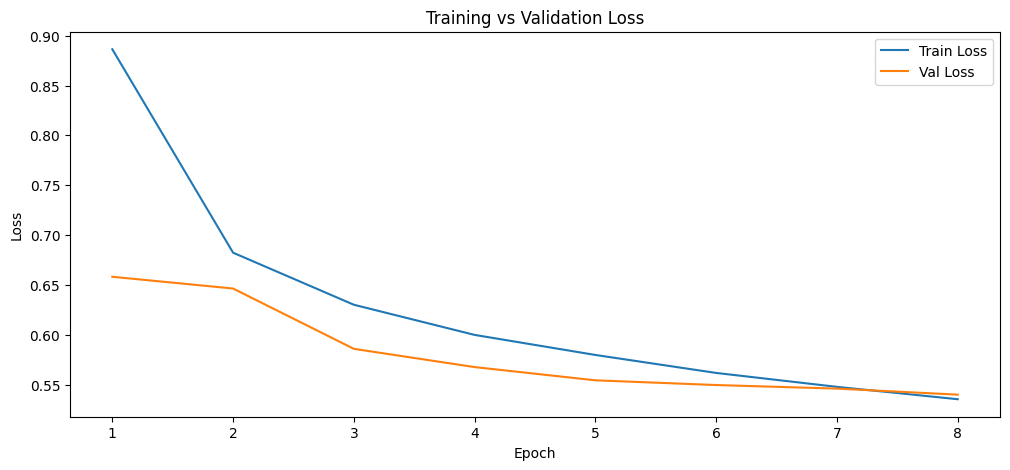

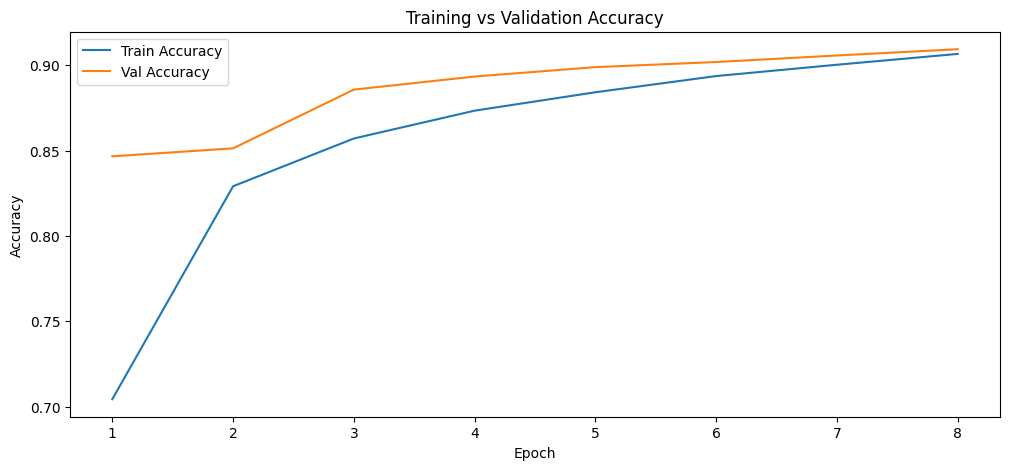

In [44]:
plot_history(
    train_losses,
    val_losses,
    train_accs,
    val_accs
)

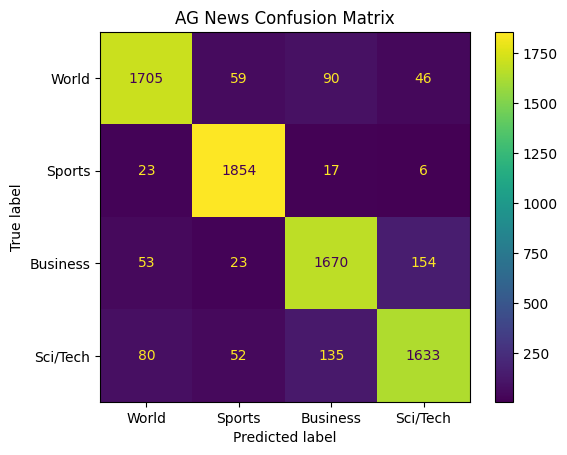

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_labels,
    test_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["World", "Sports", "Business", "Sci/Tech"]
)

disp.plot()
plt.title("AG News Confusion Matrix")
plt.show()

In [46]:
import pickle

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)